## **Well-Come to Pytorch - Classification**
## Step by step Impletation

### **Step 1: Creating a Binary Classification Dataset and Inspecting the DataSet.**

To practice binary classification, we need a dataset containing examples from two different classes.

For this lesson, we use Scikit-Learn's make_circles() function to generate a simple dataset containing two circles of points.

Each sample contains:

2 input features (X1, X2)
1 binary label (0 or 1)

The dataset is intentionally simple. It is a toy dataset, meaning it is mainly designed for learning and experimenting with machine learning concepts.

Our goal is to train a neural network that learns the relationship between the two input features and the binary class label.

In [1]:
from sklearn.datasets import make_circles
# Data creation
n_samples=1200
X,y=make_circles(n_samples,noise=0.04,random_state=42)

# View first 10 pieces of x and y
print("First 10 samples of X : \n",X[:10])
print("First 10 samples of Y :\n",y[:10])


First 10 samples of X : 
 [[ 0.772868   -0.16157011]
 [-0.71353539  0.2336328 ]
 [ 0.47642811  0.86843022]
 [-0.09552451 -1.02427945]
 [ 0.81758036  0.57191291]
 [ 0.50712568 -0.62364847]
 [-0.96718445 -0.24374726]
 [-0.55155904 -0.60186102]
 [-0.41117515 -0.92692327]
 [-0.68025066  0.32557585]]
First 10 samples of Y :
 [1 1 0 0 0 1 0 1 0 1]


### Transforming into dataframe 

In [2]:
import pandas as pd
df=pd.DataFrame({"x1":X[:,0],"x2":X[:,1],"Label":y})
df.head(10)


,x1,x2,Label
0,0.772868,-0.161570,1
1,-0.713535,0.233633,1
2,0.476428,0.868430,0
3,-0.095525,-1.024279,0
4,0.817580,0.571913,0
5,0.507126,-0.623648,1
6,-0.967184,-0.243747,0
7,-0.551559,-0.601861,1
8,-0.411175,-0.926923,0
9,-0.680251,0.325576,1


### Visualise the Circles

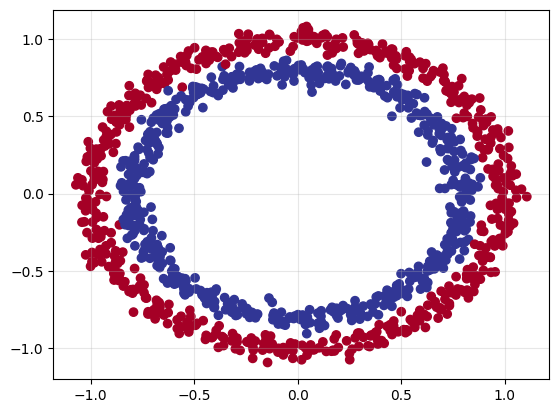

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);
plt.grid(True,alpha=0.3)

### Checking the input and output shapes.

In [4]:
x_sample=X[0]
y_sample=y[0]
print(f"Values for one samples of X: {x_sample} \n "
      f" and the same for y :{y_sample}" )

print(f"Shapes of one samples of X:{x_sample.shape}\n"
      f"and the same for y : {y_sample.shape}")

Values for one samples of X: [ 0.772868   -0.16157011] 
  and the same for y :1
Shapes of one samples of X:(2,)
and the same for y : ()


### Turn   data into tensors

In [5]:
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[ 0.7729, -0.1616],
         [-0.7135,  0.2336],
         [ 0.4764,  0.8684],
         [-0.0955, -1.0243],
         [ 0.8176,  0.5719]]),
 tensor([1., 1., 0., 0., 0.]))

### Train test split

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape

torch.Size([960, 2])

### **Step 2: Build a Model .**

###  Check the device

In [17]:
from torch import nn
device="cuda" if torch.cuda.is_available() else "Cpu"
print(f"Device : {device}")

Device : Cpu


### Creating the model

In [15]:
class Circlemodelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(
            in_features=2,
            out_features=5
        )
        self.layer2=nn.Linear(
            in_features=5,
            out_features=1
        )
    def forward(self,X):
        return self.layer2(self.layer1(X))
print("Done")

Done


### Create the model

In [19]:
model_0=Circlemodelv0()
print("Done")

Done


### Inspect the model

In [20]:
model_0

Circlemodelv0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)